The advertising dataset

In [ ]:
#download the dataset
!gdown 1Z3bs8lnk6os1n5RE7x_p75JR-1yk1sfi
!unzip advertising.zip

Downloading...
From: https://drive.google.com/uc?id=1Z3bs8lnk6os1n5RE7x_p75JR-1yk1sfi
To: /content/advertising.zip
100% 1.90k/1.90k [00:00<00:00, 5.45MB/s]
Archive:  advertising.zip
replace advertising.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: advertising.csv         


In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#libraries
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

In [ ]:
#df = pd.read_csv('advertising.csv')
#df.head()

In [ ]:
#functions to transform from csv to list
def get_column(data,index):
  result=[row[index] for row in data]
  return result

def prepare_data(file_name):
  data = np.genfromtxt(
      file_name, delimiter=',',
      skip_header=1
  ).tolist()

  N = len(data)
  #tv
  tv_data = get_column(data,0)

  #radio
  radio_data = get_column(data,1)

  #news
  news_data = get_column(data,2)

  #sales
  sales_data = get_column(data,3)

  #return the input
  X = [tv_data, radio_data, news_data]
  Y = sales_data
  return X,Y

In [ ]:
X, y = prepare_data('advertising.csv')

In [ ]:
len(X), len(y)

(3, 200)

In [ ]:
#initialization
def initialize_params():
  w1 = random.gauss(mu=0.0, sigma=0.01)
  w2 = random.gauss(mu=0.0, sigma=0.01)
  w3 = random.gauss(mu=0.0, sigma=0.01)
  b = 0
  return w1, w2, w3, b

print(initialize_params())

(0.002704191152756538, 0.010575245328854739, 0.0010348190328710275, 0)


In [ ]:
def predict(x1, x2, x3, w1, w2, w3, b):
  y_hat = w1*x1 + w2*x2 + w3*x3 + b
  return y_hat

def compute_loss(y_hat,y):
  loss = (y_hat-y)**2
  return loss

def compute_gradient_wi(y_hat,y,xi):
  dwi = 2*xi*(y_hat-y)
  return dwi

def compute_gradient_b(y_hat,y):
  db = 2*(y_hat-y)
  return db

#update
def update_weight_wi(wi, dwi, lr):
  wi = wi - lr*dwi
  return wi

def update_weight_db(b, db, lr):
  b = b - lr*db
  return b


In [ ]:
def linear_regression(X_data, y_data, epoch_max = 50, lr = 1e-5):
  losses = []
  w1, w2, w3, b = initialize_params()
  N = len(y_data)
  for epoch in range(epoch_max):
    for i in range(N):
      x1 = X_data[0][i]
      x2 = X_data[1][i]
      x3 = X_data[2][i]

      y = y_data[i]

      y_hat = predict(x1, x2, x3, w1, w2, w3, b)

      loss = compute_loss(y_hat, y)

      #compute gradient
      dL_dw1 = compute_gradient_wi(y_hat, y, x1)
      dL_dw2 = compute_gradient_wi(y_hat, y, x2)
      dL_dw3 = compute_gradient_wi(y_hat, y, x3)
      dL_db = compute_gradient_b(y_hat, y)

      #update parameters
      w1 = update_weight_wi(w1, dL_dw1, lr)
      w2 = update_weight_wi(w2, dL_dw2, lr)
      w3 = update_weight_wi(w3, dL_dw3, lr)
      b = update_weight_db(b, dL_db, lr)

      #update logging
      losses.append(loss)
  return (w1, w2, w3, b, losses)

[291.38564549523926, 22.233220504774494, 65.75545487956491, 8.351897755363016, 5.4610516987767825, 12.808993174340518, 25.29961083431755, 0.18105706862545104, 14.857151183317272, 28.814389950285463, 41.21565152145375, 4.779458962348413, 17.53246909528685, 28.687768838605326, 5.601052446407204, 10.412399147105836, 0.031984549026595394, 31.846798538853704, 33.850700668101496, 8.120799266500828, 4.607549408093141, 0.0011657885288139172, 5.620746706406574, 9.06697899382972, 11.307683611418831, 49.8340671807301, 41.1079063178969, 7.876603435450211, 12.471361513423085, 13.705229510435075, 4.094963414117922, 9.60984524216195, 29.41279730741479, 11.705889851605152, 35.59767770264163, 8.181404734536953, 95.89000647503731, 6.959589401125418, 5.985627297094033, 51.01844160325204, 2.7946972487601194, 1.7357043520534912, 7.870314744693929, 15.410312100120484, 11.56475673286884, 0.008999212891848815, 1.7589526244899856, 2.058941149977369, 10.978335105025689, 6.299991493004304, 0.34066620364457034, 8

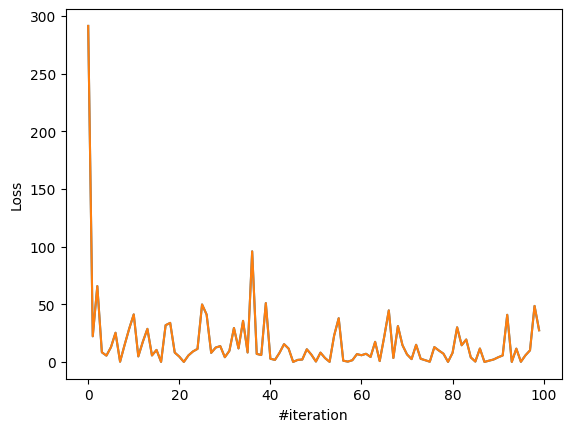

In [ ]:
(w1, w2, w3, b, losses) = linear_regression(X,y)
print(losses[0:100])
plt.plot(losses[0:100])
plt.plot(losses[0:100])
plt.xlabel("#iteration")
plt.ylabel("Loss")
plt.show()

In [ ]:
#min-max scaling
def min_max_scaling(X):
  mins = []
  maxs = []
  X_scaled = []

  #finding min max for each feature
  for feature in X:
    min_val = min(feature)
    max_val = max(feature)
    mins.append(min_val)
    maxs.append(max_val)

    scaled_feature = []
    for x in feature:
      scaled_x = (x-min_val)/(max_val - min_val)
      scaled_feature.append(scaled_x)

    X_scaled.append(scaled_feature)

  return X_scaled, mins, maxs